In [ ]:
# =============================================================================
# COMPLETE SALES EDA 
# Dataset: Amazon_sales.xlsx (3203 rows, 10 cols)
# Author: Ayaan Sayed | GitHub: AyaanSayedAnalytics
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

#1 Loading and Inspection
sales = pd.read_excel('Amazon_sales.xlsx')
print("Shape:", sales.shape)
print("\nFirst 2 rows:")
print(sales.head(2))
print("\nColumn types:")
print(sales.dtypes)
print("\nQuick stats (numeric):")
print(sales.describe().round(2))


Shape: (3203, 10)

First 2 rows:
         Order ID Order Date  Ship Date                   EmailID  \
0  CA-2013-138688 2013-06-13 2013-06-17   DarrinVanHuff@gmail.com   
1  CA-2011-115812 2011-06-09 2011-06-14  BrosinaHoffman@gmail.com   

                              Geography     Category  \
0  United States,Los Angeles,California       Labels   
1  United States,Los Angeles,California  Furnishings   

                                        Product Name  Sales  Quantity   Profit  
0  Self-Adhesive Address Labels for Typewriters b...  14.62         2   6.8714  
1  Eldon Expressions Wood and Plastic Desk Access...  48.86         7  14.1694  

Column types:
Order ID                object
Order Date      datetime64[ns]
Ship Date       datetime64[ns]
EmailID                 object
Geography               object
Category                object
Product Name            object
Sales                  float64
Quantity                 int64
Profit                 float64
dtype: object

Quick s

In [ ]:
#2 Data Cleaning & Preparation

missing = sales.isna().sum()
print('Missing values:\n',missing)
duplicates = sales.duplicated().sum()
print('\nDuplicates Present:',duplicates)

#Converting dates
sales['Order Date'] = pd.to_datetime(sales['Order Date'])
sales['Ship Date'] = pd.to_datetime(sales['Ship Date'])

#Date Features
sales['Year'] = sales['Order Date'].dt.year 
sales['Month'] = sales['Order Date'].dt.month 
sales['Quarter'] = sales['Order Date'].dt.quarter
sales['YearMonth'] = sales['Order Date'].dt.to_period('M')

#Negative values check
numeric_cols = sales.select_dtypes(include='number') 
print("\nNegative values per numeric column:\n", (numeric_cols < 0).sum())


Missing values:
 Order ID        0
Order Date      0
Ship Date       0
EmailID         0
Geography       0
Category        0
Product Name    0
Sales           0
Quantity        0
Profit          0
Year            0
Month           0
Quarter         0
YearMonth       0
dtype: int64

Duplicates Present: 0

Negative values per numeric column:
 Sales         0
Quantity      0
Profit      318
Year          0
Month         0
Quarter       0
dtype: int64


In [ ]:
#3 KPI Summary
total_sales = sales['Sales'].sum()
total_profit = sales['Profit'].sum()
total_orders = sales['Order ID'].nunique()
total_customers = sales['EmailID'].nunique()
avg_order_value = total_sales / total_orders

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", round(avg_order_value, 2))



Total Sales: 725457.82
Total Profit: 108418.45
Total Orders: 1611
Total Customers: 686
Average Order Value: 450.32


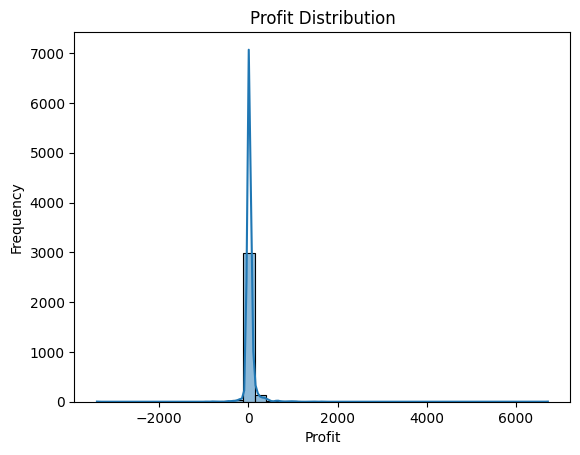

In [ ]:
#4 Profit Distribution
sns.histplot(sales['Profit'], kde=True, bins=40)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()


Category
Bookcases      -1646.5117
Machines        -618.9264
Fasteners        275.1907
Supplies         626.0465
Tables          1482.6073
Envelopes       1908.7624
Labels          2303.1223
Art             2374.0970
Chairs          4027.5843
Furnishings     7641.2704
Appliances      8261.2699
Storage         8645.3222
Phones          9110.7426
Paper          12119.2364
Binders        16096.8016
Accessories    16484.5983
Copiers        19327.2351
Name: Profit, dtype: float64


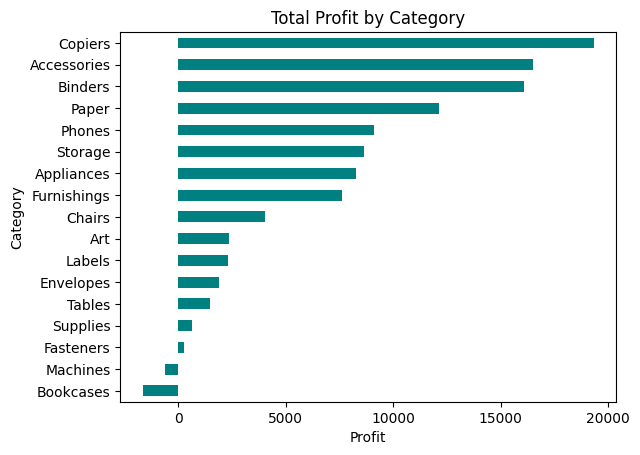

In [ ]:
#5 Category Profitability
category_profit = sales.groupby('Category')['Profit'].sum().sort_values()
print(category_profit)

category_profit.plot(kind='barh', color='teal')
plt.title("Total Profit by Category")
plt.xlabel("Profit")
plt.ylabel("Category")
plt.show()


In [131]:
#6 Product Profitability 
print('\nTop 10 best products:\n',sales.groupby('Product Name')['Profit'].sum().nlargest(10).reset_index())
loss_products = sales[sales['Profit'] < 0]
print('Top 10 worst products:\n',loss_products.groupby('Product Name')['Profit'].sum().nsmallest(10).reset_index())


Top 10 best products:
                                         Product Name     Profit
0              Canon imageCLASS 2200 Advanced Copier  6719.9808
1  Fellowes PB500 Electric Punch Plastic Comb Bin...  3050.3760
2                 Canon PC1060 Personal Laser Copier  2267.9676
3               Hewlett Packard LaserJet 3310 Copier  2183.9636
4  LogitechÂ Z-906 Speaker sys - home theater - 5...  1715.9480
5  Plantronics Savi W720 Multi-Device Wireless He...  1670.9220
6               Ibico EPK-21 Electric Binding System  1644.2913
7                                 Canon PC940 Copier  1480.4671
8                LogitechÂ P710e Mobile Speakerphone  1418.7699
9                      Canon Image Class D660 Copier  1379.9770
Top 10 worst products:
                                         Product Name     Profit
0          Lexmark MX611dhe Monochrome Laser Printer -3399.9800
1  Zebra GK420t Direct Thermal/Thermal Transfer P...  -938.2800
2         O'Sullivan 4-Shelf Bookcase in Odessa Pine  -8

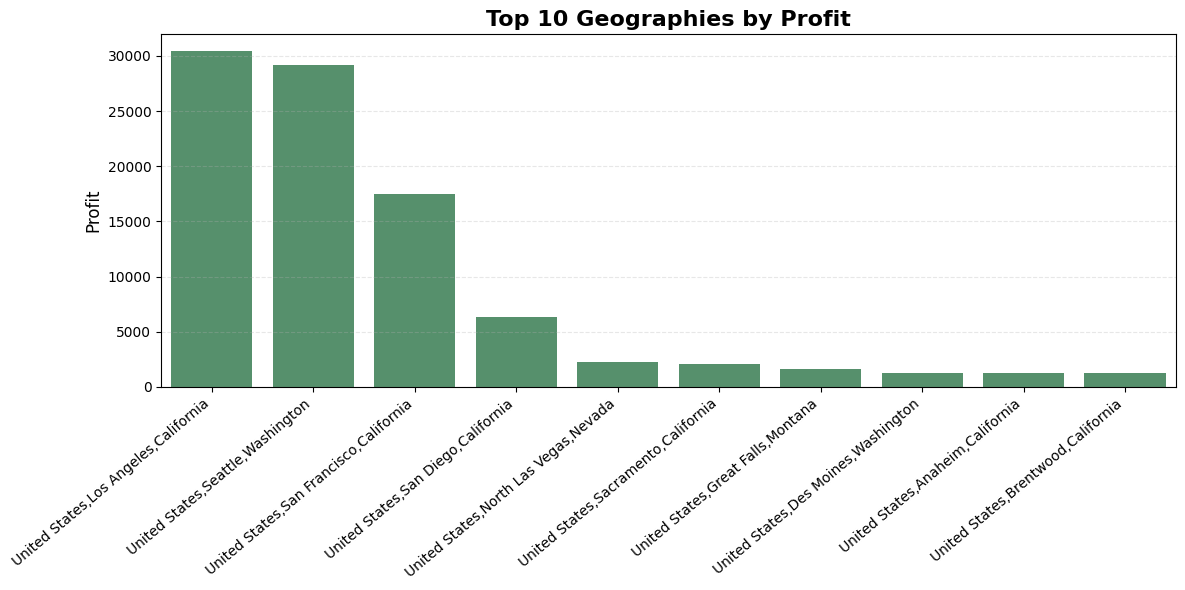

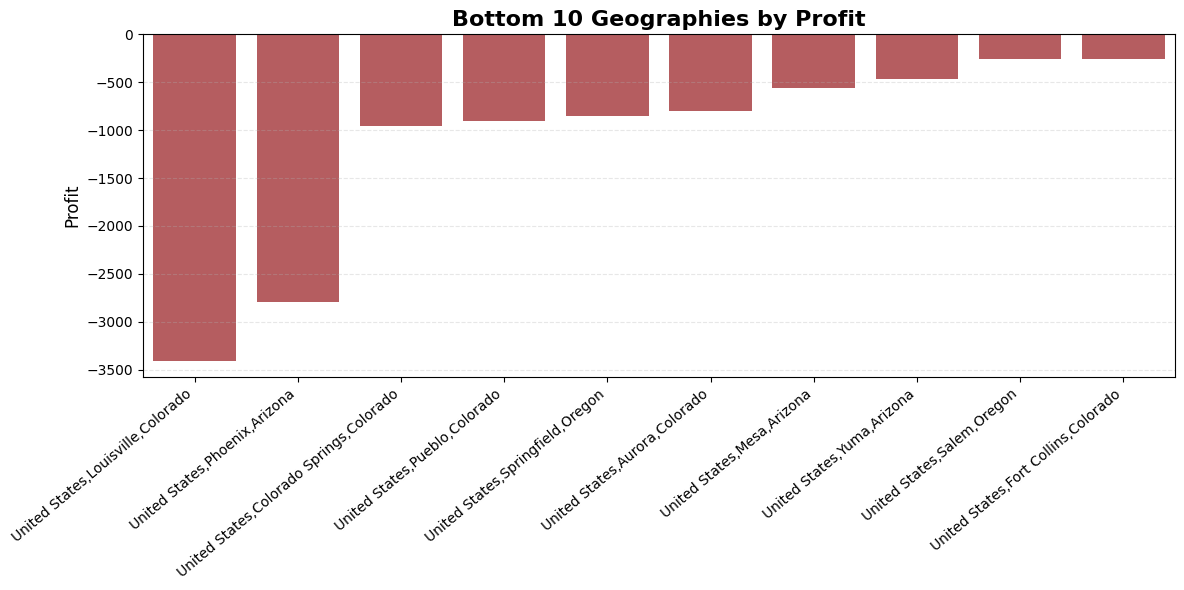

In [ ]:
#7 Geographic Profitability 
geo_top10 = (
    sales.groupby('Geography')['Profit']
    .sum()
    .nlargest(10)
    .reset_index()
)

geo_bottom10 = (
    sales.groupby('Geography')['Profit']
    .sum()
    .nsmallest(10)
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.barplot(data=geo_top10, x='Geography', y='Profit', color='#4C9A6A')
plt.title("Top 10 Geographies by Profit", fontsize=16, weight='bold')
plt.xticks(rotation=40, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
sns.barplot(data=geo_bottom10, x='Geography', y='Profit', color='#C44E52')
plt.title("Bottom 10 Geographies by Profit", fontsize=16, weight='bold')
plt.xticks(rotation=40, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

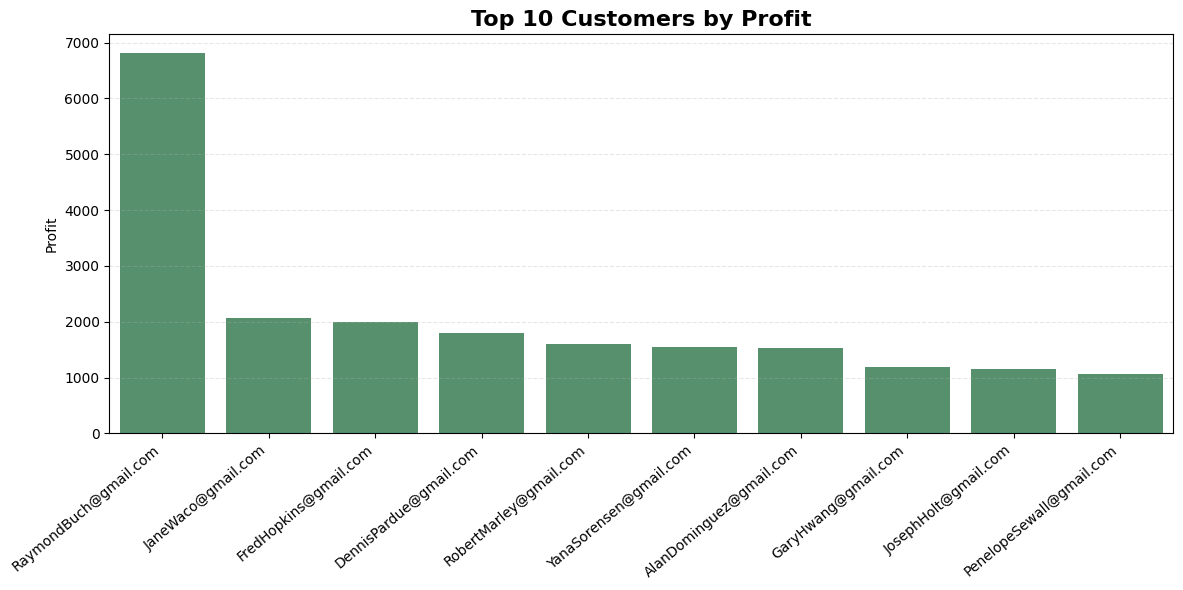

In [ ]:
#8 Customer Profitability
customer_profit = (
    sales.groupby('EmailID')['Profit']
    .sum()
    .nlargest(10)
    .reset_index()
)
plt.figure(figsize=(12,6))
sns.barplot(
    data=customer_profit,
    x='EmailID',
    y='Profit',
    color='#4C9A6A'
)
plt.title("Top 10 Customers by Profit", fontsize=16, weight='bold')
plt.xlabel("")
plt.ylabel("Profit")
plt.xticks(rotation=40, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


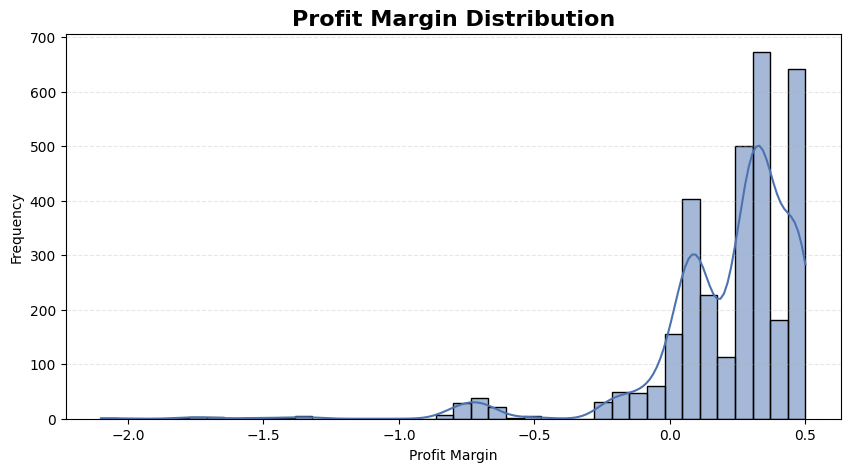

In [ ]:
#9 Profit Margin Distribution (part a)
sales['Profit_Margin'] = sales['Profit'] / sales['Sales']
plt.figure(figsize=(10,5))
sns.histplot(sales['Profit_Margin'], kde=True, bins=40, color='#4C72B0')
plt.title("Profit Margin Distribution", fontsize=16, weight='bold')
plt.xlabel("Profit Margin")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()



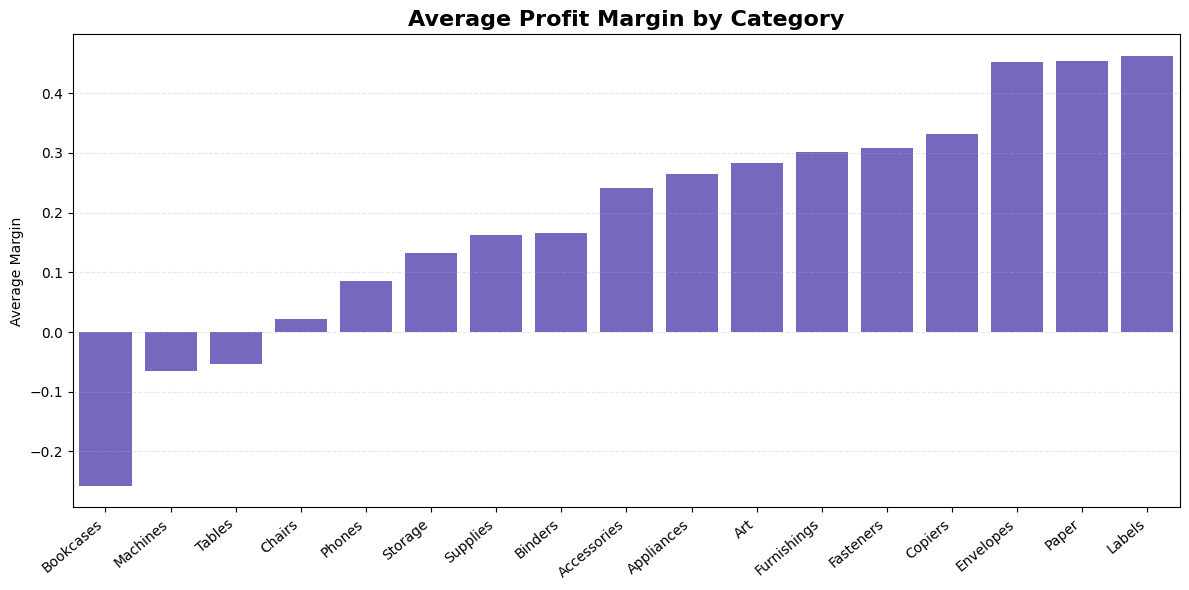

In [ ]:
#9 Profit Margin Analysis (part b)
margin_by_cat = (
    sales.groupby('Category')['Profit_Margin']
    .mean()
    .sort_values()
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=margin_by_cat,
    x='Category',
    y='Profit_Margin',
    color='#6A5ACD'
)
plt.title("Average Profit Margin by Category", fontsize=16, weight='bold')
plt.xlabel("")
plt.ylabel("Average Margin")
plt.xticks(rotation=40, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()
